<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analyis__cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1D CNN Test RMSE: 2.7758


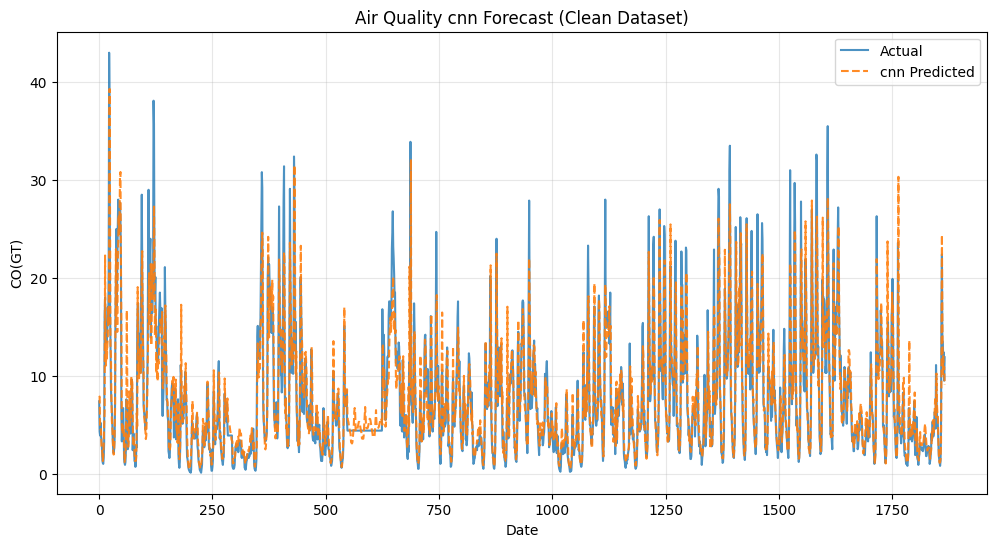

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input
from tensorflow.keras.models import Sequential

air_quality_df = pd.read_csv("/content/AirQualityUCI.csv", sep=";", decimal=",")
air_quality_df = air_quality_df.dropna(how="all").dropna(axis=1, how="all")

# Combine Date and Time into a single datetime column and sort
air_quality_df["Datetime"] = pd.to_datetime(
    air_quality_df["Date"] + " " + air_quality_df["Time"], format="%d/%m/%Y %H.%M.%S"
)
air_quality_df = air_quality_df.sort_values("Datetime").reset_index(drop=True)

# Handle UCI missing value placeholders (-200) by replacing with NaN and forward-filling
air_quality_df = air_quality_df.replace(-200, np.nan)
air_quality_df = air_quality_df.ffill().bfill()

# Target: Predict Benzene (C6H6(GT)) concentrations
target = "C6H6(GT)"

# 2. Time Series Feature Engineering
# Create Lag features (previous 1, 2, and 24 hours)
air_quality_df["lag_1"] = air_quality_df[target].shift(1)
air_quality_df["lag_2"] = air_quality_df[target].shift(2)
air_quality_df["lag_24"] = air_quality_df[target].shift(24)

# Create Rolling Window features (4-hour moving average)
air_quality_df["rolling_mean_4"] = air_quality_df[target].shift(1).rolling(window=4).mean()

# Create Calendar features
air_quality_df["hour"] = air_quality_df["Datetime"].dt.hour
air_quality_df["day_of_week"] = air_quality_df["Datetime"].dt.dayofweek

# Drop rows with NaN values created by shifting
air_quality_df = air_quality_df.dropna().reset_index(drop=True)

# Define feature columns
features = ["lag_1", "lag_2", "lag_24", "rolling_mean_4", "hour", "day_of_week"]

# 3. Train/Test Split (Time-series aware)
split_idx = int(len(air_quality_df) * 0.8)
train_air_quality_df = air_quality_df.iloc[:split_idx]
test_air_quality_df = air_quality_df.iloc[split_idx:]

X_train_raw, y_train = train_air_quality_df[features].values, train_air_quality_df[target].values
X_test_raw, y_test = test_air_quality_df[features].values, test_air_quality_df[target].values

# 4. Scale Data (Crucial for Neural Network convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Reshape input to be 3D [samples, time_steps, features] for 1D CNN
# We treat the 6 engineered features as 6 parallel time steps/channels
X_train = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# 5. Build 1D CNN Architecture
model = Sequential(
    [
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        # First 1D Convolutional layer to extract temporal patterns
        Conv1D(filters=64, kernel_size=2, activation="relu"),
        # Flatten the 3D multi-channel output to a 1D vector
        Flatten(),
        # Fully connected hidden layer
        Dense(32, activation="relu"),
        # Output layer for regression (linear activation)
        Dense(1),
    ]
)

model.compile(optimizer="adam", loss="mse")

# 6. Train the Model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,  # Turn off verbose output to keep notebook clean
)

# 7. Predict and Evaluate
predictions = model.predict(X_test).flatten()
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"1D CNN Test RMSE: {rmse:.4f}")
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test)), y_test, label="Actual", color="tab:blue", alpha=0.8)
plt.plot(
    np.arange(len(predictions)),
    predictions,
    label="cnn Predicted",
    color="tab:orange",
    linestyle="--",
    alpha=0.9,
)
plt.title("Air Quality cnn Forecast (Clean Dataset)")
plt.xlabel("Date")
plt.ylabel("CO(GT)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()